## Step 2: Nelson Siegel curve fitting


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [22]:
def nelson_siegel(t, beta0, beta1, beta2, lamb):
    return beta0 + (beta1 + beta2) * (1 - np.exp(-t / lamb)) / (t / lamb) - beta2 * np.exp(-t / lamb)

In [23]:
def error(params, t, y):
    return np.sum((nelson_siegel(t, *params) - y) ** 2)

In [24]:
df = pd.read_csv('raw_yield_curve_data.csv')
t = df['maturity_years'].values
y = df['yield'].values

print("Raw Yield Curve Data:")
print(df)
print(f"\nMaturities: {t}")
print(f"Yields: {y}")

Raw Yield Curve Data:
    maturity_years  yield
0         0.083333   3.72
1         0.250000   3.67
2         0.500000   3.58
3         1.000000   3.44
4         2.000000   3.47
5         3.000000   3.55
6         5.000000   3.74
7         7.000000   3.97
8        10.000000   4.21
9        20.000000   4.79
10       30.000000   4.85

Maturities: [ 0.08333333  0.25        0.5         1.          2.          3.
  5.          7.         10.         20.         30.        ]
Yields: [3.72 3.67 3.58 3.44 3.47 3.55 3.74 3.97 4.21 4.79 4.85]


In [25]:
beta0_guess = y[-1]                
beta1_guess = y[0] - y[-1]        
beta2_guess = 0                  
lamb_guess = 0                     

initial_guess = [beta0_guess, beta1_guess, beta2_guess, lamb_guess]

bounds = [
    (0, 10),       
    (-10, 10),      
    (-10, 10),        
    (0.1, 10)       
]

In [26]:
result = minimize(
    error,
    initial_guess,
    args=(t, y),
    bounds=bounds,
    method="L-BFGS-B"
)
print(result.success)
print(result.message)
print("\nFitted Parameters:")
print(f"beta0: {result.x[0]:.4f}")
print(f"beta1: {result.x[1]:.4f}")
print(f"beta2: {result.x[2]:.4f}")
print(f"lambda: {result.x[3]:.4f}")

True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Fitted Parameters:
beta0: 5.2212
beta1: -1.4862
beta2: -3.1042
lambda: 2.1841


In [27]:
beta0, beta1, beta2, lamb = result.x

print("beta0:", beta0)
print("beta1:", beta1)
print("beta2:", beta2)
print("lamb:", lamb)


beta0: 5.221198490579299
beta1: -1.4862105014118083
beta2: -3.1041970876293363
lamb: 2.1840669078410304


In [28]:
def yield_curve(maturity):
    return nelson_siegel(maturity, beta0, beta1, beta2, lamb)


In [29]:
print(yield_curve(4.5))
print(yield_curve(6.2))


3.672599453839253
3.8803308507436554


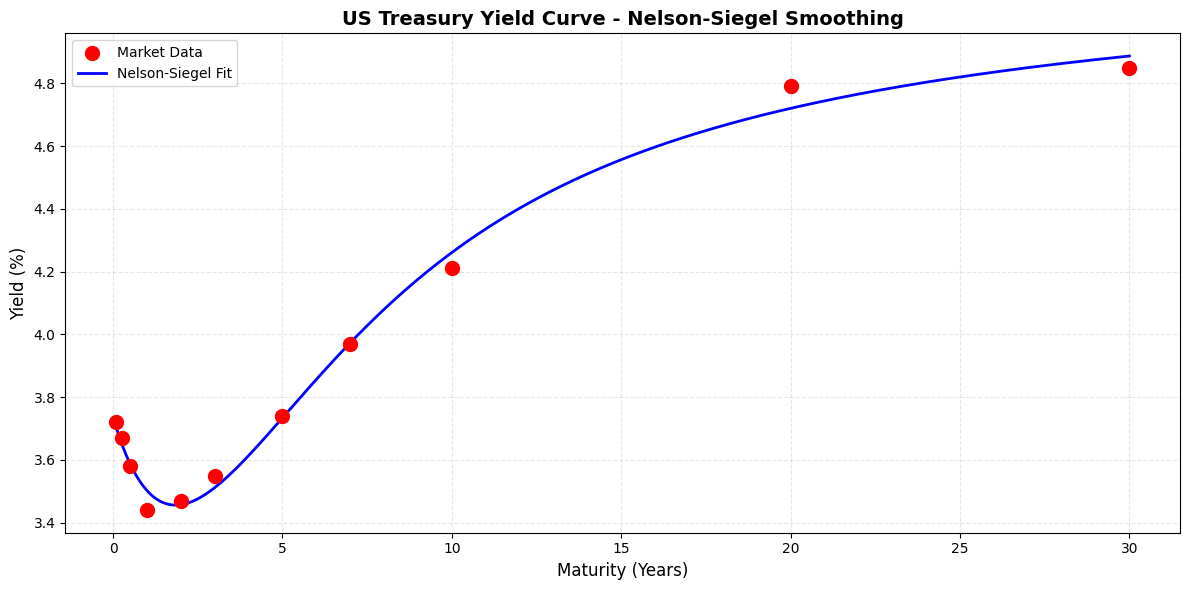

In [30]:
t_grid = np.linspace(min(t), max(t), 300)
fitted_yields = yield_curve(t_grid)

plt.figure(figsize=(12, 6))
plt.scatter(t, y, color="red", s=100, label="Market Data", zorder=3)
plt.plot(t_grid, fitted_yields, 'b-', linewidth=2, label="Nelson-Siegel Fit")
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.title("US Treasury Yield Curve - Nelson-Siegel Smoothing", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 3: Bond pricing engine 

In [31]:
def present_value(face_value, coupon_rate, yield_rate, time):

    N = time*2
    PMT = face_value * coupon_rate / 2
    r = yield_rate / 2

    pv_coupons = PMT * (1 - (1 + r) ** -N) / r
    pv_face = face_value / (1 + r) ** N
    return pv_coupons + pv_face

In [32]:
tenors = [1/12, 0.25,0.5, 1, 2, 3, 5, 7, 10, 20, 30]

print("Bond Pricing:")
print("-" * 70)
results = []
for t in tenors:
    market_yield = yield_curve(t)
    coupon = market_yield
    price = present_value(1000, coupon, market_yield, t)
    print(f"Maturity: {t:5.2f}Y | Market Yield: {market_yield:5.2f}% | Price: ${price:7.2f}")
    results.append({'maturity': t, 'market_yield': market_yield, 'price': price})

df_results = pd.DataFrame(results)

Bond Pricing:
----------------------------------------------------------------------
Maturity:  0.08Y | Market Yield:  3.71% | Price: $1000.00
Maturity:  0.25Y | Market Yield:  3.65% | Price: $1000.00
Maturity:  0.50Y | Market Yield:  3.59% | Price: $1000.00
Maturity:  1.00Y | Market Yield:  3.50% | Price: $1000.00
Maturity:  2.00Y | Market Yield:  3.46% | Price: $1000.00
Maturity:  3.00Y | Market Yield:  3.51% | Price: $1000.00
Maturity:  5.00Y | Market Yield:  3.73% | Price: $1000.00
Maturity:  7.00Y | Market Yield:  3.97% | Price: $1000.00
Maturity: 10.00Y | Market Yield:  4.26% | Price: $1000.00
Maturity: 20.00Y | Market Yield:  4.72% | Price: $1000.00
Maturity: 30.00Y | Market Yield:  4.89% | Price: $1000.00


## Step 4: Roll-Down Simulation (6-Month Horizon)

In [33]:
H = 0.5
face_value = 1000


step = 0.1  # 0.1y ≈ 1.2 months
max_maturity = 30.0

tenor_grid = np.arange(H + step, max_maturity + 1e-9, step)
roll_results = []
for t in tenor_grid:
    market_yield = float(yield_curve(t))      # %
    coupon = market_yield                     # coupon ≈ yield assumption

    price_today = present_value(face_value, coupon/100, market_yield/100, t)

    new_maturity = t - H
    new_yield = float(yield_curve(new_maturity))

    price_after_6m = present_value(face_value, coupon/100, new_yield/100, new_maturity)

    roll_results.append({
        "maturity": t,
        "price_today": price_today,
        "new_maturity": new_maturity,
        "price_after_6m": price_after_6m,
        "roll_down_change": price_after_6m - price_today
    })

df_roll = pd.DataFrame(roll_results)
df_roll.head()

,maturity,price_today,new_maturity,price_after_6m,roll_down_change
0,0.6,1000.0,0.1,999.867767,-0.132233
1,0.7,1000.0,0.2,999.761948,-0.238052
2,0.8,1000.0,0.3,999.680193,-0.319807
3,0.9,1000.0,0.4,999.620317,-0.379683
4,1.0,1000.0,0.5,999.580296,-0.419704


## Step 5: Return Decomposition (Carry + Roll-Down + HPR)


In [34]:
step5_results = []

for index, row in df_roll.iterrows():
    
    maturity = row["maturity"]
    price_today = row["price_today"]
    price_after = row["price_after_6m"]
    
    market_yield = yield_curve(maturity)
    
    coupon_payment = (market_yield/100 * 1000) / 2
    
    carry_return = coupon_payment / price_today
    
    roll_return = (price_after - price_today) / price_today
    
    hpr = carry_return + roll_return
    
    step5_results.append({
        "maturity": maturity,
        "carry_return": carry_return,
        "roll_down_return": roll_return,
        "total_HPR": hpr
    })

df_step5 = pd.DataFrame(step5_results)

df_step5

,maturity,carry_return,roll_down_return,total_HPR
0,0.6,0.017829,-0.000132,0.017697
1,0.7,0.017734,-0.000238,0.017496
2,0.8,0.017649,-0.000320,0.017329
3,0.9,0.017574,-0.000380,0.017195
4,1.0,0.017510,-0.000420,0.017090
...,...,...,...,...
290,29.6,0.024412,0.000900,0.025312
291,29.7,0.024418,0.000895,0.025313
292,29.8,0.024424,0.000890,0.025314
293,29.9,0.024429,0.000885,0.025315


## Step 6

In [35]:
def macaulay_and_modified_duration(face_value, coupon_rate_annual, ytm_annual, maturity_years, freq=2):
    """
    Semiannual coupons by default (freq=2).
    Returns: (macaulay_duration_years, modified_duration_years, price)
    """
    N = max(1, int(np.floor(maturity_years * freq)))
    c = face_value * coupon_rate_annual / freq
    y = ytm_annual / freq

    cashflows = np.full(N, c, dtype=float)
    cashflows[-1] += face_value

    periods = np.arange(1, N + 1)
    discount = (1 + y) ** (-periods)

    pv = cashflows * discount
    price = pv.sum()

    times_years = periods / freq
    D_mac = (times_years * pv).sum() / price
    D_mod = D_mac / (1 + y)   # y is per-period yield

    return D_mac, D_mod, price


risk_rows = []
FACE = 1000
dy_1bp = 0.0001  # 1 basis point

for _, row in df_roll.iterrows():
    maturity = float(row["maturity"])
    price_today = float(row["price_today"])

    ytm_pct = float(yield_curve(maturity))  #yield_curve returns %
    ytm = ytm_pct / 100.0                    # convert to decimal

    # coupon ≈ current yield 
    coupon_rate = ytm

    D_mac, D_mod, model_price = macaulay_and_modified_duration(
        face_value=FACE,
        coupon_rate_annual=coupon_rate,
        ytm_annual=ytm,
        maturity_years=maturity,
        freq=2
    )

    approx_dP_over_P_1bp = -D_mod * dy_1bp
    approx_dP_1bp = approx_dP_over_P_1bp * price_today  # scale by  actual priced bond today

    risk_rows.append({
        "maturity": maturity,
        "macaulay_duration": D_mac,
        "modified_duration": D_mod,
        "approx_%ΔP_1bp": approx_dP_over_P_1bp,   # decimal (e.g., -0.0012 = -0.12%)
        "approx_$ΔP_1bp": approx_dP_1bp
    })

df_step6 = pd.DataFrame(risk_rows)

df_step5_with_risk = df_step5.merge(df_step6, on="maturity", how="left")
df_step5_with_risk

,maturity,carry_return,roll_down_return,total_HPR,macaulay_duration,modified_duration,approx_%ΔP_1bp,approx_$ΔP_1bp
0,0.6,0.017829,-0.000132,0.017697,0.500000,0.491241,-0.000049,-0.049124
1,0.7,0.017734,-0.000238,0.017496,0.500000,0.491288,-0.000049,-0.049129
2,0.8,0.017649,-0.000320,0.017329,0.500000,0.491329,-0.000049,-0.049133
3,0.9,0.017574,-0.000380,0.017195,0.500000,0.491365,-0.000049,-0.049136
4,1.0,0.017510,-0.000420,0.017090,0.500000,0.491396,-0.000049,-0.049140
...,...,...,...,...,...,...,...,...
290,29.6,0.024412,0.000900,0.025312,15.925223,15.545714,-0.001555,-1.554571
291,29.7,0.024418,0.000895,0.025313,15.923253,15.543704,-0.001554,-1.554370
292,29.8,0.024424,0.000890,0.025314,15.921297,15.541708,-0.001554,-1.554171
293,29.9,0.024429,0.000885,0.025315,15.919354,15.539726,-0.001554,-1.553973


## Step 7

In [36]:
df_opt = df_step5_with_risk.copy()

# Find index of max HPR

best_idx = np.argmax(df_opt["total_HPR"].values)

#optimal row
best_row = df_opt.iloc[best_idx]

optimal_maturity = float(best_row["maturity"])
optimal_expected_return = float(best_row["total_HPR"])

print("Optimal maturity (years):", optimal_maturity)
print("Max expected total_HPR:", optimal_expected_return)

best_row

Optimal maturity (years): 29.999999999999993
Max expected total_HPR: 0.025315567169103492


maturity             30.000000
carry_return          0.024435
roll_down_return      0.000881
total_HPR             0.025316
macaulay_duration    15.917424
modified_duration    15.537758
approx_%ΔP_1bp       -0.001554
approx_$ΔP_1bp       -1.553776
Name: 294, dtype: float64

In [37]:
best_roll = df_step5_with_risk.loc[df_step5_with_risk["roll_down_return"].idxmax()]

# sweet spot by roll-down per duration (risk-adjusted roll-down)
df_step5_with_risk["roll_per_dur"] = df_step5_with_risk["roll_down_return"] / df_step5_with_risk["modified_duration"]
best_roll_riskadj = df_step5_with_risk.loc[df_step5_with_risk["roll_per_dur"].idxmax()]

best_roll, best_roll_riskadj

(maturity             8.200000
 carry_return         0.020499
 roll_down_return     0.003345
 total_HPR            0.023844
 macaulay_duration    6.900701
 modified_duration    6.762083
 approx_%ΔP_1bp      -0.000676
 approx_$ΔP_1bp      -0.676208
 Name: 76, dtype: float64,
 maturity             5.500000
 carry_return         0.018977
 roll_down_return     0.002788
 total_HPR            0.021766
 macaulay_duration    4.601110
 modified_duration    4.515420
 approx_%ΔP_1bp      -0.000452
 approx_$ΔP_1bp      -0.451542
 roll_per_dur         0.000618
 Name: 49, dtype: float64)

In [38]:
# dynamic roll-down recommendation (highest 6M roll-down return)

best_roll = df_step5_with_risk.loc[df_step5_with_risk["roll_down_return"].idxmax()]

rec_maturity = float(best_roll["maturity"])
rec_roll = float(best_roll["roll_down_return"])

print(
    f"Recommendation: Target ~{rec_maturity:.2f}Y maturity, "
    f"which has the highest projected 6M roll-down return of {rec_roll*100:.4f}% "
    f"based on the interpolated yield curve."
)

Recommendation: Target ~8.20Y maturity, which has the highest projected 6M roll-down return of 0.3345% based on the interpolated yield curve.


In [39]:
# risk-adjusted sweet spot by roll-down per duration 
df_step5_with_risk["roll_per_dur"] = df_step5_with_risk["roll_down_return"] / df_step5_with_risk["modified_duration"]
best_roll_riskadj = df_step5_with_risk.loc[df_step5_with_risk["roll_per_dur"].idxmax()]

rec_maturity_ra = float(best_roll_riskadj["maturity"])
rec_roll_ra = float(best_roll_riskadj["roll_down_return"])
rec_eff = float(best_roll_riskadj["roll_per_dur"])

print(
    f"Risk-adjusted sweet spot: ~{rec_maturity_ra:.2f}Y maturity, "
    f"roll-down {rec_roll_ra*100:.4f}% over 6M, "
    f"efficiency (roll-down / mod duration) = {rec_eff:.6f}."
)

Risk-adjusted sweet spot: ~5.50Y maturity, roll-down 0.2788% over 6M, efficiency (roll-down / mod duration) = 0.000618.
